In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('C:/Users/Admin/Downloads/transactions_.csv')
df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,net_change_org,net_change_dest,ratio_amount_orig,ratio_amount_dest,orig_zero_after,dest_zero_after
0,8,158007,0,0,474016,1618631,0,0,1144615,15800711999,0,1,0
1,236,457948,0,0,2720411,3178359,0,0,457948,45794829999,0,1,0
2,37,153602,11160428,11314031,3274930,3121327,0,153603,-153603,0,0,0,0
3,331,49555,10865,0,0,49555,0,-10865,49555,4,4955514000,1,0
4,250,29648,0,0,56933,86581,0,0,29648,2964802000,0,1,0


```
Univariate Analysis Using Histogram...

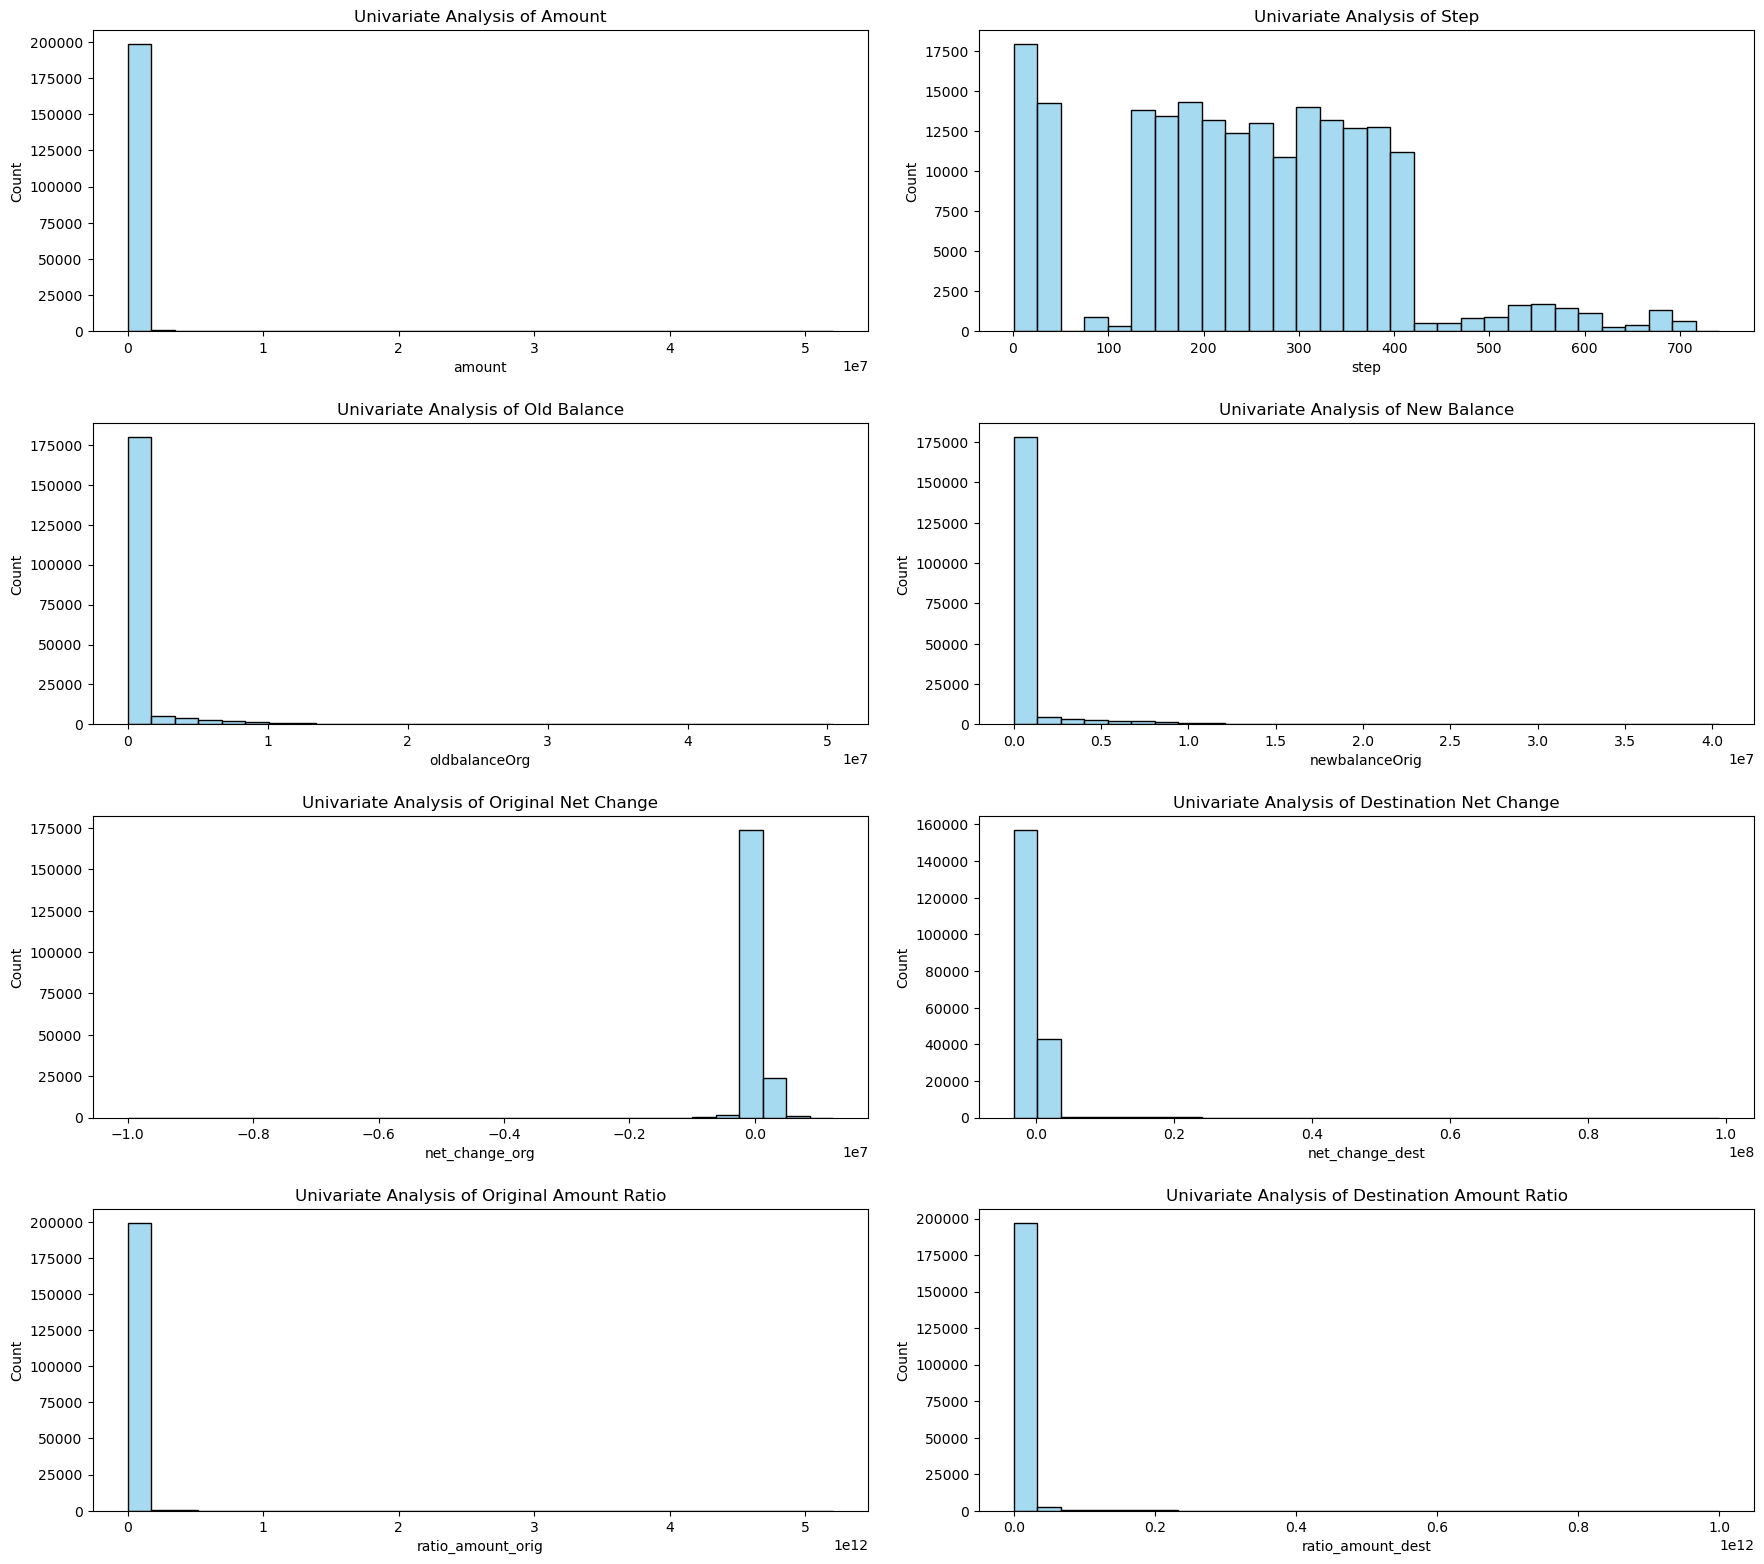

In [5]:
fig, ax = plt.subplots(4, 2, figsize=(18, 16))

ax1 = sns.histplot(data=df, x='amount', bins=30, ax=ax[0, 0], color='skyblue')
ax1.set_title('Univariate Analysis of Amount')

ax2 = sns.histplot(data=df, x='step', bins=30, ax=ax[0, 1], color='skyblue')
ax2.set_title('Univariate Analysis of Step')

ax3 = sns.histplot(data=df, x='oldbalanceOrg',  bins=30, ax=ax[1, 0], color='skyblue')
ax3.set_title('Univariate Analysis of Old Balance')

ax4 = sns.histplot(data=df, x='newbalanceOrig', bins=30, ax=ax[1, 1], color='skyblue')
ax4.set_title('Univariate Analysis of New Balance')

ax5 = sns.histplot(data=df, x='net_change_org', bins=30, ax=ax[2, 0], color='skyblue')
ax5.set_title('Univariate Analysis of Original Net Change')

ax6 = sns.histplot(data=df, x='net_change_dest', bins=30, ax=ax[2, 1], color='skyblue')
ax6.set_title('Univariate Analysis of Destination Net Change')

ax7 = sns.histplot(data=df, x='ratio_amount_orig', bins=30, ax=ax[3, 0], color='skyblue')
ax7.set_title('Univariate Analysis of Original Amount Ratio')

ax8 = sns.histplot(data=df, x='ratio_amount_dest', bins=30, ax=ax[3, 1], color='skyblue')
ax8.set_title('Univariate Analysis of Destination Amount Ratio')

plt.tight_layout(pad=2)
plt.show()

```
Univariate Analysis Using Boxplot & Violin-plot...

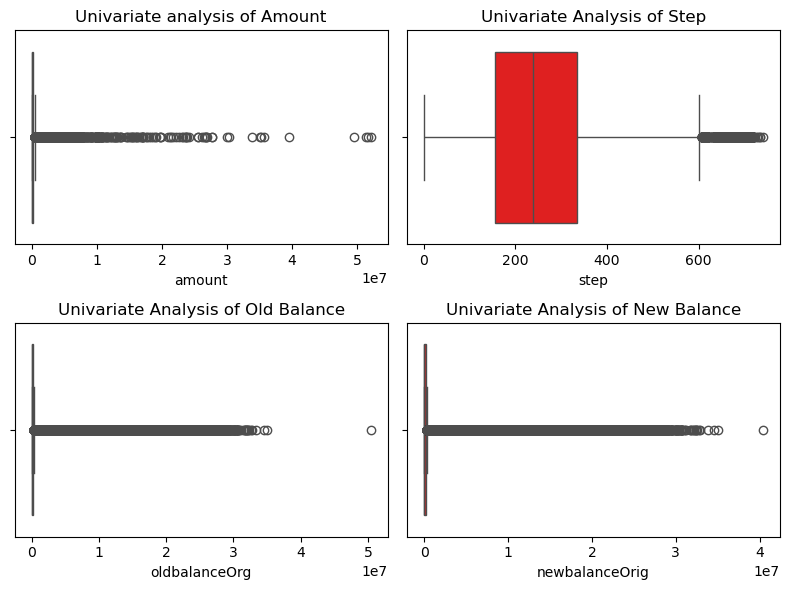

In [3]:
fig, ax = plt.subplots(2, 2, figsize=(8, 6))

ax1 = sns.boxplot(data=df, x='amount', ax=ax[0, 0], color='red')
ax1.set_title('Univariate analysis of Amount')

ax2 = sns.boxplot(data=df, x='step', ax=ax[0, 1], color='red')
ax2.set_title('Univariate Analysis of Step')

ax3 = sns.boxplot(data=df, x='oldbalanceOrg', ax=ax[1, 0], color='red')
ax3.set_title('Univariate Analysis of Old Balance')

ax4 = sns.boxplot(data=df, x='newbalanceOrig', ax=ax[1, 1], color='red')
ax4.set_title('Univariate Analysis of New Balance')

plt.tight_layout()
plt.show()

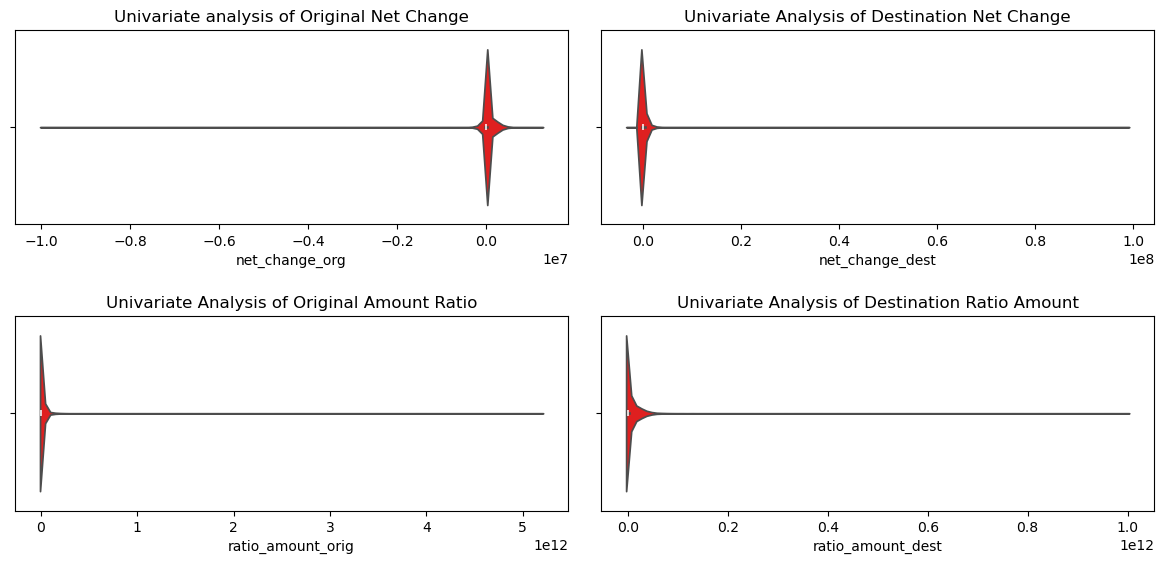

In [11]:
fig, ax = plt.subplots(2, 2, figsize=(12, 6))

ax1 = sns.violinplot(data=df, x='net_change_org', ax=ax[0, 0], color='red')
ax1.set_title('Univariate analysis of Original Net Change')

ax2 = sns.violinplot(data=df, x='net_change_dest', ax=ax[0, 1], color='red')
ax2.set_title('Univariate Analysis of Destination Net Change')

ax3 = sns.violinplot(data=df, x='ratio_amount_orig', ax=ax[1, 0], color='red')
ax3.set_title('Univariate Analysis of Original Amount Ratio')

ax4 = sns.violinplot(data=df, x='ratio_amount_dest', ax=ax[1, 1], color='red')
ax4.set_title('Univariate Analysis of Destination Ratio Amount')

plt.tight_layout(pad=2)
plt.show()

```
Univariate Analysis Using Bar Chart...

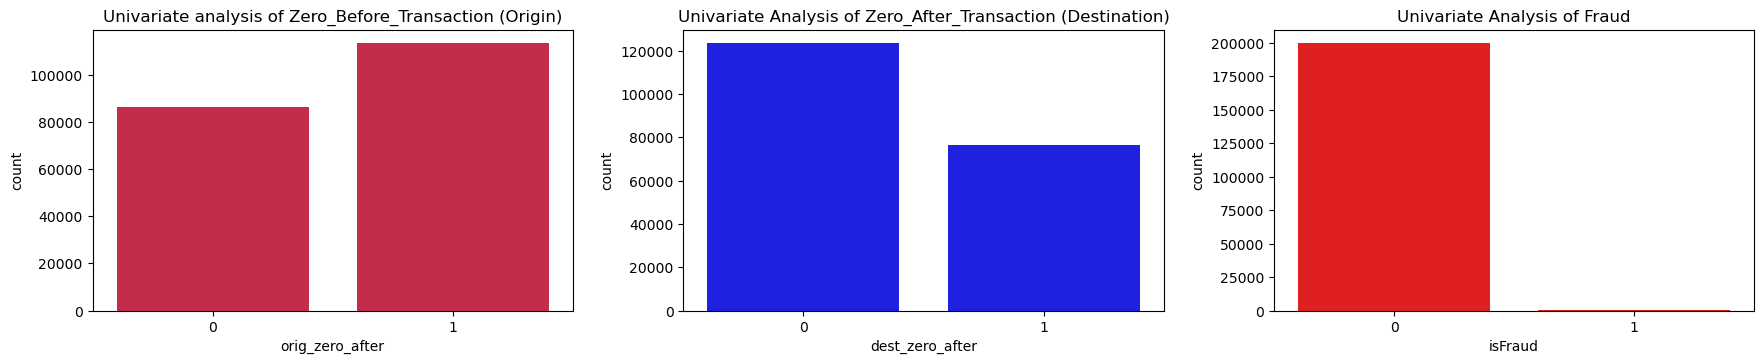

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4))

ax1 = sns.countplot(data=df, x='orig_zero_after', ax=ax[0], color='crimson')
ax1.set_title('Univariate analysis of Zero_Before_Transaction (Origin)')

ax2 = sns.countplot(data=df, x='dest_zero_after', ax=ax[1], color='blue')
ax2.set_title('Univariate Analysis of Zero_After_Transaction (Destination)')

ax3 = sns.countplot(data=df, x='isFraud', ax=ax[2], color='red')
ax3.set_title('Univariate Analysis of Fraud')

plt.tight_layout(pad=2)
plt.show()

```
Univariate Analysis Using Pie Chart...

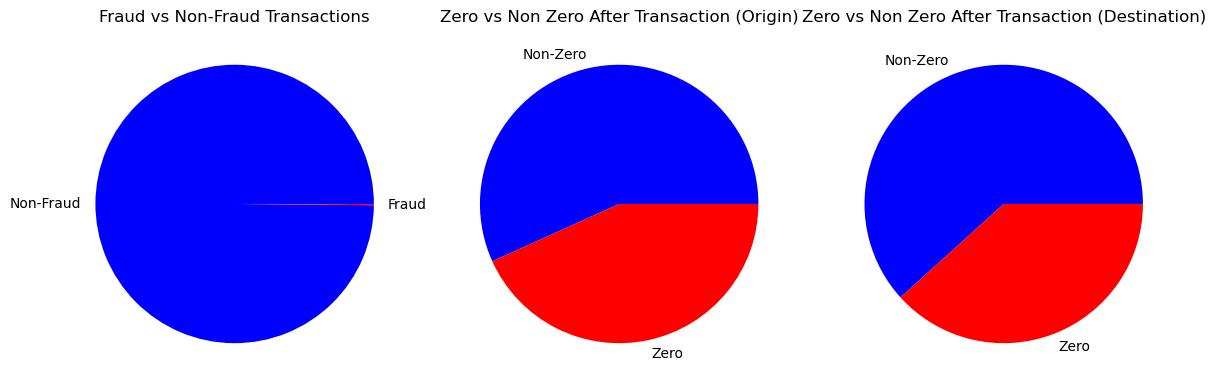

In [46]:
fraud_counts = df['isFraud'].value_counts()
origin_zero_counts = df['orig_zero_after'].value_counts()
dest_zero_counts = df['dest_zero_after'].value_counts()

colors = ['blue', 'red']
labels = ['Non-Fraud', 'Fraud']
labels1 = ['Non-Zero', 'Zero']

plt.figure(figsize=(12, 8))
plt.subplot(131)
plt.pie(fraud_counts, labels=labels, colors=colors)
plt.title('Fraud vs Non-Fraud Transactions')

plt.subplot(132)
plt.pie(origin_zero_counts, labels=labels1, colors=colors)
plt.title('Zero vs Non Zero After Transaction (Origin)')

plt.subplot(133)
plt.pie(dest_zero_counts, labels=labels1, colors=colors)
plt.title('Zero vs Non Zero After Transaction (Destination)')
plt.tight_layout(pad=1)

plt.show()

*Personal Comments*:

Fraud makes up only ~0.14% of transactions.

Features like origin going to zero and destination going to zero seem meaningful — they may help differentiate fraud vs normal.

This dataset is extremely imbalanced, which is typical in fraud detection. Most transactions are legitimate.

For modeling, this means I’ll need imbalanced learning strategies (SMOTE, undersampling, cost-sensitive models, anomaly detection, etc.).

I’ll need to check conditional distributions (e.g., pie charts or barplots split by isFraud) to confirm how much these features correlate with fraud.



The pie chart shows how often the origin account balance goes to zero after a transaction.

In fraud cases, fraudsters often drain the account completely, leaving zero balance.